In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ipywidgets as widget
from IPython.display import display

df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.dropna(subset=["type","title","country","release_year","cast","director"],inplace=True)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5336 entries, 7 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5336 non-null   object
 1   type          5336 non-null   object
 2   title         5336 non-null   object
 3   director      5336 non-null   object
 4   cast          5336 non-null   object
 5   country       5336 non-null   object
 6   date_added    5336 non-null   object
 7   release_year  5336 non-null   int64 
 8   rating        5335 non-null   object
 9   duration      5333 non-null   object
 10  listed_in     5336 non-null   object
 11  description   5336 non-null   object
dtypes: int64(1), object(11)
memory usage: 541.9+ KB


In [4]:
df['type'].value_counts()


type
Movie      5189
TV Show     147
Name: count, dtype: int64

TypeError: ylabel() missing 1 required positional argument: 'ylabel'

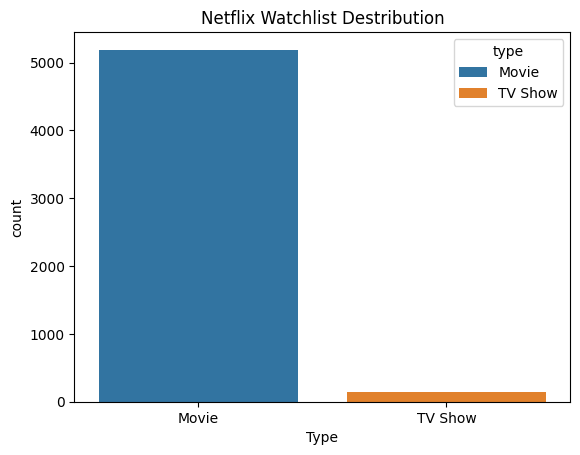

In [5]:
count_df = df['type'].value_counts().reset_index()
count_df.columns = ['type', 'count']  

sns.barplot(data=count_df, x='type', y='count', hue='type', legend=True)
plt.title("Netflix Watchlist Destribution")
plt.xlabel("Type")
plt.ylabel()
plt.show()


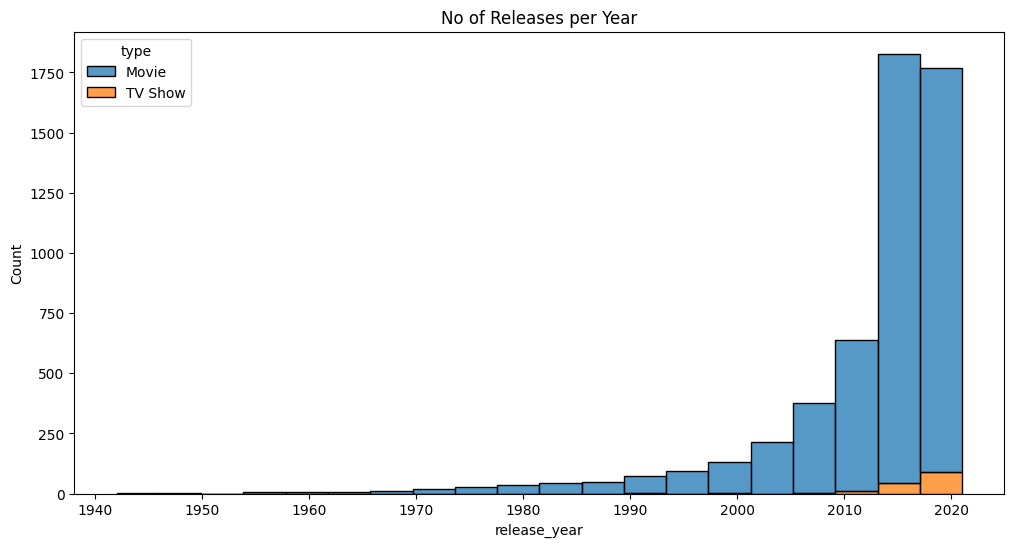

In [ ]:
df['release_year']=df['release_year'].astype(int)
plt.figure(figsize=(12,6))
sns.histplot(data=df,x='release_year',bins=20,hue='type',multiple='stack')
plt.title("No of Releases per Year")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10136\2502964839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_countries.index,x=top_countries.values,palette="Set2")


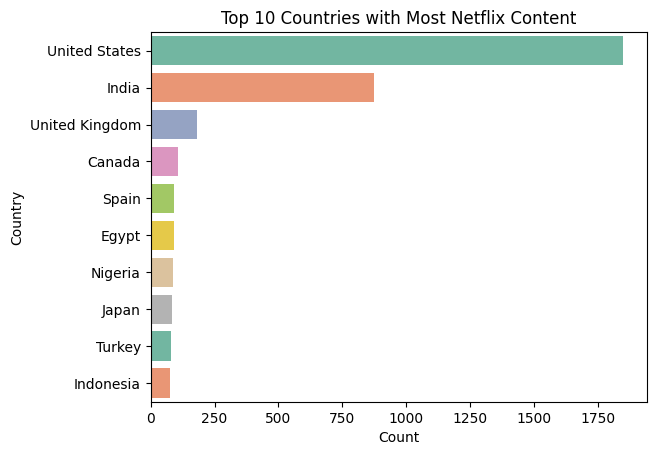

In [ ]:
top_countries = df['country'].value_counts().head(10)
sns.barplot(y=top_countries.index,x=top_countries.values,palette="Set2")
plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10136\3561129173.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_genre.index,x=top_genre.values, palette='viridis')


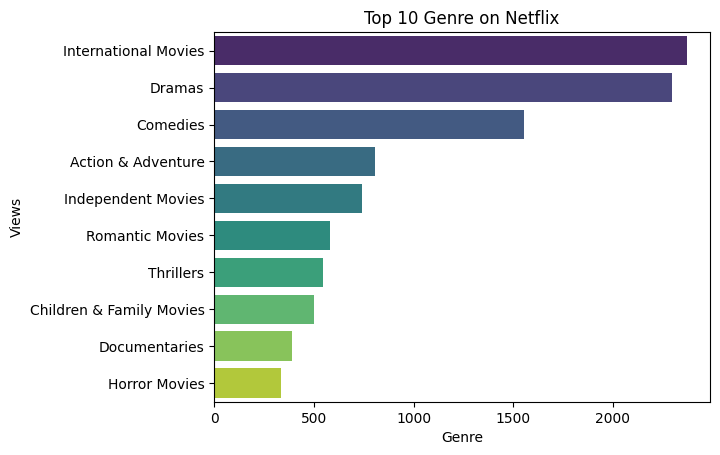

In [ ]:
df['genres'] =df['listed_in'].str.split(', ')
genre_ex = df.explode('genres')

top_genre=genre_ex['genres'].value_counts().head(10)
sns.barplot(y=top_genre.index,x=top_genre.values, palette='viridis')
plt.title("Top 10 Genre on Netflix")
plt.ylabel("Views")
plt.xlabel("Genre")
plt.show()

In [ ]:
df_filtered=df[(df['type']=='TV Show')& (df['country']=='India')& (df['release_year']>2015)]
df_filtered[['title','release_year','listed_in']].head()

,title,release_year,listed_in
297,Navarasa,2021,TV Shows
1293,Pitta Kathalu,2021,"International TV Shows, TV Dramas"
1520,Paava Kadhaigal,2020,"International TV Shows, TV Dramas"
3036,Jamtara - Sabka Number Ayega,2020,"Crime TV Shows, International TV Shows, TV Dramas"
4685,GHOUL,2018,"International TV Shows, TV Dramas, TV Horror"
